In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
import pickle
from lightgbm import LGBMRegressor

In [ ]:
df = pd.read_csv("car_seats_filled.csv")

In [3]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [5]:
df.isnull()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,False,False,False,False,False,False,False,False,False,False,False,False,False
8124,False,False,False,False,False,False,False,False,False,False,False,False,False
8125,False,False,False,False,False,False,False,False,False,False,False,False,False
8126,False,False,False,False,False,False,False,False,False,False,False,False,False


In [6]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        222
torque           222
seats              0
dtype: int64

In [7]:
df['mileage'] = df['mileage'].str.split().str[0].astype(float)
df['engine'] = df['engine'].str.split().str[0].astype(float)
df['max_power'] = df['max_power'].str.split().str[0].astype(float)

In [8]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0


In [9]:
df['mileage'] = df['mileage'].fillna(
    df.groupby(['name', 'fuel'])['mileage'].transform('mean')
)

df['mileage'] = df['mileage'].fillna(
    df.groupby('fuel')['mileage'].transform('median')
)


In [10]:
df['engine'] = df['engine'].fillna(
    df.groupby(['name', 'fuel'])['engine'].transform('mean')
)

df['engine'] = df['engine'].fillna(
    df.groupby('fuel')['engine'].transform('median')
)

In [11]:
df['max_power'] = df['max_power'].fillna(
    df.groupby(['name', 'fuel'])['max_power'].transform('mean')
)

df['max_power'] = df['max_power'].fillna(
    df.groupby('fuel')['max_power'].transform('median')
)

In [12]:
df.drop('torque', axis = 1, inplace=True)

In [13]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

In [14]:
df['brand'] = df['name'].str.split().str[0]

In [15]:
df['brand'].unique()

array(['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault',
       'Mahindra', 'Tata', 'Chevrolet', 'Fiat', 'Datsun', 'Jeep',
       'Mercedes-Benz', 'Mitsubishi', 'Audi', 'Volkswagen', 'BMW',
       'Nissan', 'Lexus', 'Jaguar', 'Land', 'MG', 'Volvo', 'Daewoo',
       'Kia', 'Force', 'Ambassador', 'Ashok', 'Isuzu', 'Opel', 'Peugeot'],
      dtype=object)

In [16]:
le = LabelEncoder()
df['fuel'] = le.fit_transform(df['fuel'])


cols = ['brand', 'seller_type', 'transmission', 'owner']

for col in cols:
    df[col] = le.fit_transform(df[col])



In [17]:
df.drop('name', axis = 1, inplace=True)

In [18]:
df.columns

Index(['year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats',
       'brand'],
      dtype='object')

In [19]:
df.isnull().sum()

year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
brand            0
dtype: int64

In [20]:
x = df.drop('selling_price',axis=1)
y = df['selling_price']

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [22]:
lr = LinearRegression()
rf = RandomForestRegressor()
gboost = GradientBoostingRegressor()
xgboost = XGBRegressor(
    n_estimators = 100,
    max_depth = 6,
    learning_rate = 0.1,
    random_state = 42
)
lightgbm = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.01,
    max_depth=6
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001090 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 6502, number of used features: 11
[LightGBM] [Info] Start training from score 638656.852815


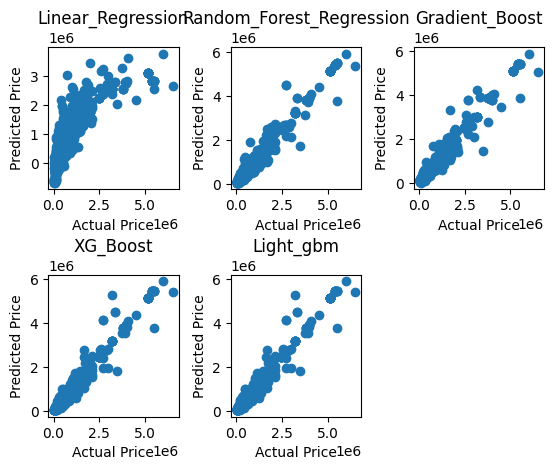

In [23]:
lr.fit(x_train, y_train)
lr_res = lr.predict(x_test)

plt.subplots_adjust(
    wspace=0.4,   # width gap between columns
    hspace=0.6    # height gap between rows
)

plt.subplot(2,3,1)
plt.scatter(y_test, lr_res)
plt.title('Linear_Regression')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
res1 = r2_score(y_test, lr_res)


rf.fit(x_train, y_train)
rf_res = rf.predict(x_test)

plt.subplot(2,3,2)
plt.scatter(y_test, rf_res)
plt.title('Random_Forest_Regression')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
res2 = r2_score(y_test, rf_res)


gboost.fit(x_train, y_train)
gb_res = gboost.predict(x_test)

plt.subplot(2,3,3)
plt.scatter(y_test, gb_res)
plt.title('Gradient_Boost')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
res3 = r2_score(y_test, gb_res)


xgboost.fit(x_train, y_train)
xgb_res = xgboost.predict(x_test)

plt.subplot(2,3,4)
plt.scatter(y_test, xgb_res)
plt.title('XG_Boost')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
res4 = r2_score(y_test, xgb_res)


lightgbm.fit(x_train, y_train)
lgb_res = lightgbm.predict(x_test)

plt.subplot(2,3,5)
plt.scatter(y_test, xgb_res)
plt.title('Light_gbm')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
res5 = r2_score(y_test, lgb_res)

In [24]:
print("LinearRegression =", res1)
print("Random Forest =", res2)
print("Gradient Boost =", res3)
print("XG Boost =", res4)
print("LightGBM =", res5)

LinearRegression = 0.6880843962942726
Random Forest = 0.967154833908671
Gradient Boost = 0.9604491761212341
XG Boost = 0.9649010300636292
LightGBM = 0.8276433460422407


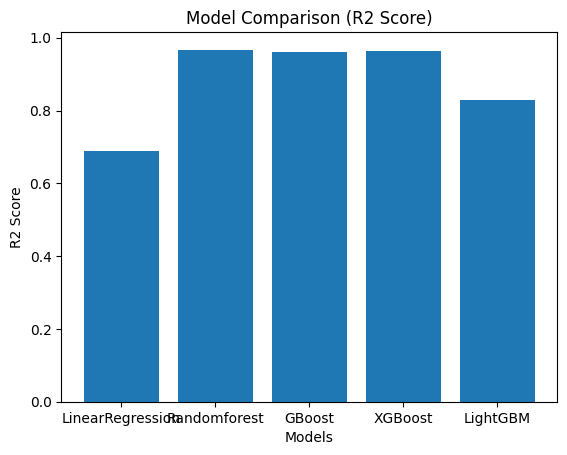

In [25]:
model=['LinearRegression', 'Randomforest', 'GBoost', 'XGBoost', 'LightGBM']
r2_score = [res1, res2, res3, res4, res5]

plt.bar(model, r2_score)

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison (R2 Score)")

plt.show()

In [26]:
pickle.dump(xgboost, open('xgboost.pkl','wb'))

pickle.dump(x.columns, open('columns.pkl','wb'))